# iFood Case - Data Architect
## Analise visual das corridas de yellow taxi (NYC TLC)

Notebook de analise com graficos sobre a camada Gold do pipeline.
Responde as duas perguntas do case com visualizacoes.

Pre-requisito: ter executado 00_setup, 01_ingestion, 02_silver e 03_gold.
As tabelas ifood_case.gold.* precisam existir.

In [0]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

IFOOD_RED = "#EA1D2C"
DARK      = "#1A1A1A"
GRAY      = "#8A8A8A"
LGRAY     = "#F4F4F4"
GREEN     = "#1B7A3E"
AMBER     = "#B45309"
BLUE      = "#1565C0"

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": GRAY,
    "axes.labelcolor": DARK,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlecolor": DARK,
    "xtick.color": GRAY,
    "ytick.color": GRAY,
    "font.size": 11,
})
print("Estilo configurado.")

Estilo configurado.


## Secao 1 – Profiling da Bronze (qualidade da fonte)

Analise exploratoria dos dados brutos **antes** de qualquer limpeza.
Justifica cada regra aplicada na camada Silver.

In [0]:
# Carga dos dados de profiling diretamente da Bronze
profiling = {
    "total_linhas"      : 16186386,
    "vendors"           : 3,
    "nulos_passenger"   : 428665,
    "nulos_total_amount": 0,
    "passageiro_zero"   : 273481,
    "valor_negativo"    : 141407,
    "timestamp_invertido": 6181,
    "fora_do_periodo"   : 104,
    "min_valor"         : -982.95,
    "max_valor"         : 6304.90,
    "media_valor"       : 27.84,
    "data_mais_antiga"  : "2001-01-01",
    "data_mais_recente" : "2023-09-05",
}

print("=== PROFILING DA BRONZE ===")
for k, v in profiling.items():
    print(f"  {k:<25}: {v:,}" if isinstance(v, (int, float)) and not isinstance(v, bool) else f"  {k:<25}: {v}")

=== PROFILING DA BRONZE ===
  total_linhas             : 16,186,386
  vendors                  : 3
  nulos_passenger          : 428,665
  nulos_total_amount       : 0
  passageiro_zero          : 273,481
  valor_negativo           : 141,407
  timestamp_invertido      : 6,181
  fora_do_periodo          : 104
  min_valor                : -982.95
  max_valor                : 6,304.9
  media_valor              : 27.84
  data_mais_antiga         : 2001-01-01
  data_mais_recente        : 2023-09-05


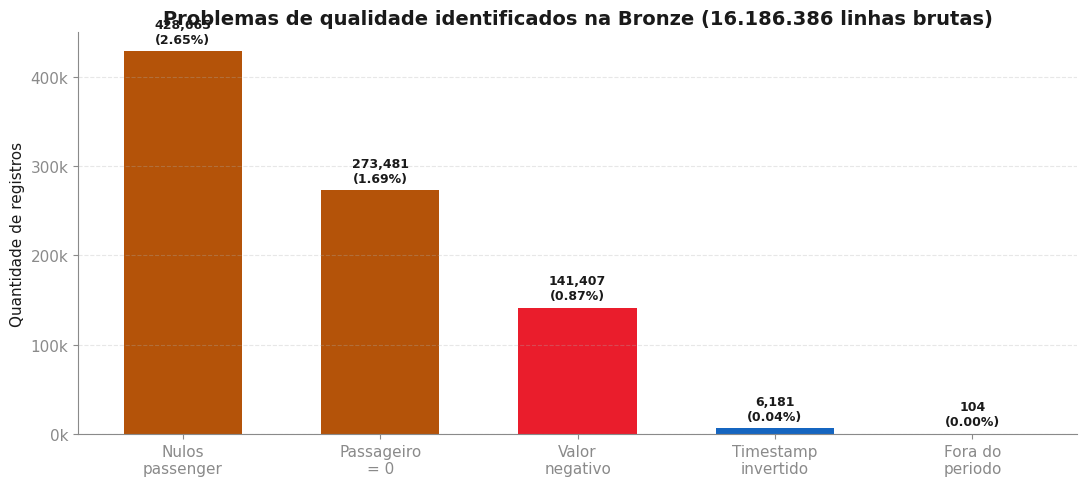

Total de registros com problemas: 849,838 (5.25% do volume bruto)


In [0]:
# Grafico 1: Distribuicao de problemas de qualidade por tipo
labels  = ["Nulos\npassenger", "Passageiro\n= 0", "Valor\nnegativo", "Timestamp\ninvertido", "Fora do\nperiodo"]
valores = [428665, 273481, 141407, 6181, 104]
cores   = [AMBER, AMBER, IFOOD_RED, BLUE, GRAY]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, valores, color=cores, width=0.6)

for b, v in zip(bars, valores):
    pct = v / profiling["total_linhas"] * 100
    ax.annotate(f"{v:,}\n({pct:.2f}%)",
                (b.get_x() + b.get_width()/2, v),
                textcoords="offset points", xytext=(0, 6),
                ha="center", fontsize=9, fontweight="bold", color=DARK)

ax.set_title("Problemas de qualidade identificados na Bronze (16.186.386 linhas brutas)")
ax.set_ylabel("Quantidade de registros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

total_problemas = sum(valores)
print(f"Total de registros com problemas: {total_problemas:,} ({total_problemas/profiling['total_linhas']*100:.2f}% do volume bruto)")

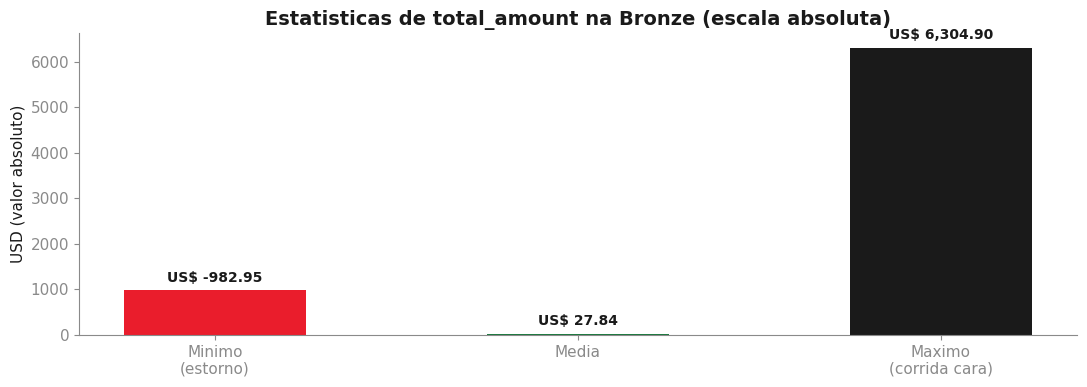

Nota: o valor minimo de -US$ 982.95 confirma a presenca de estornos que distorceriam as medias.


In [0]:
# Grafico 2: Distribuicao do total_amount na fonte (contexto min/max)
fig, ax = plt.subplots(figsize=(11, 4))

# Representacao visual das estatisticas
stats = {
    "Minimo\n(estorno)": -982.95,
    "Media": 27.84,
    "Maximo\n(corrida cara)": 6304.90
}

xs = [0, 1, 2]
ys = [abs(v) for v in stats.values()]
cs = [IFOOD_RED, GREEN, DARK]

bars = ax.bar(xs, ys, color=cs, width=0.5)
ax.set_xticks(xs)
ax.set_xticklabels(stats.keys())
ax.set_title("Estatisticas de total_amount na Bronze (escala absoluta)")
ax.set_ylabel("USD (valor absoluto)")

for b, (label, val) in zip(bars, stats.items()):
    ax.annotate(f"US$ {val:,.2f}",
                (b.get_x() + b.get_width()/2, b.get_height()),
                textcoords="offset points", xytext=(0, 6),
                ha="center", fontsize=10, fontweight="bold", color=DARK)

plt.tight_layout()
plt.show()
print("Nota: o valor minimo de -US$ 982.95 confirma a presenca de estornos que distorceriam as medias.")

## Secao 2 – Impacto da limpeza (Bronze → Silver)

Mostra quanto foi removido, por qual motivo e o aproveitamento final.

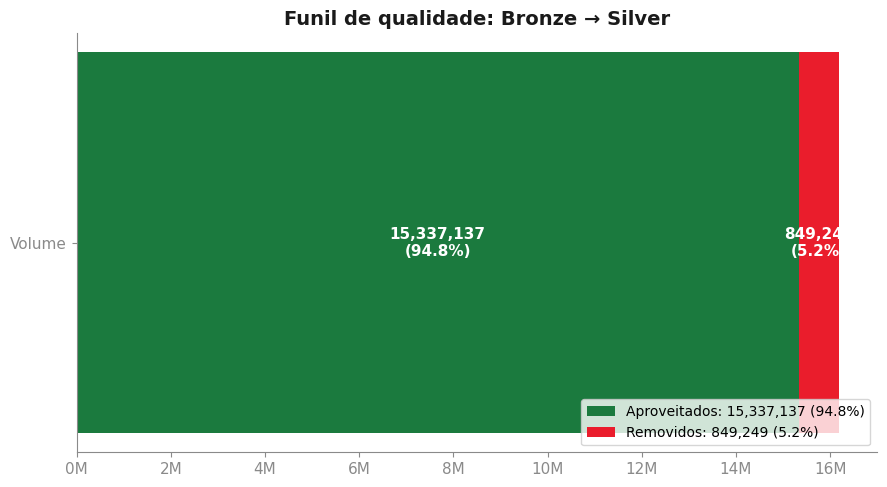

In [0]:
# Grafico 3: Funil Bronze -> Silver
bronze = 16186386
silver = 15337137
removidos = bronze - silver
pct_ok = silver / bronze * 100
pct_rm = removidos / bronze * 100

fig, ax = plt.subplots(figsize=(9, 5))

# Barra empilhada horizontal
ax.barh(["Volume"], [silver],   color=GREEN,     height=0.5, label=f"Aproveitados: {silver:,} ({pct_ok:.1f}%)")
ax.barh(["Volume"], [removidos], color=IFOOD_RED, height=0.5, left=silver, label=f"Removidos: {removidos:,} ({pct_rm:.1f}%)")

ax.set_xlim(0, bronze * 1.05)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v/1e6)}M"))
ax.set_title("Funil de qualidade: Bronze → Silver")
ax.legend(loc="lower right", fontsize=10)

ax.annotate(f"{silver:,}\n({pct_ok:.1f}%)", (silver/2, 0),
            ha="center", va="center", color="white", fontsize=11, fontweight="bold")
ax.annotate(f"{removidos:,}\n({pct_rm:.1f}%)", (silver + removidos/2, 0),
            ha="center", va="center", color="white", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

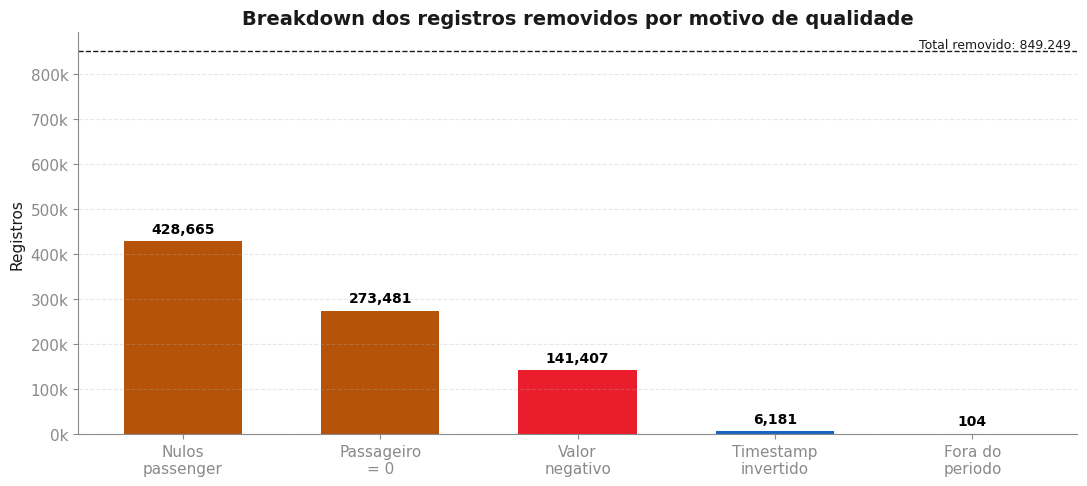

Nota: um registro pode ter multiplos problemas, por isso a soma dos motivos supera o total removido.


In [0]:
# Grafico 4: Breakdown dos removidos por motivo
motivos = ["Nulos\npassenger", "Passageiro\n= 0", "Valor\nnegativo", "Timestamp\ninvertido", "Fora do\nperiodo"]
qtds    = [428665, 273481, 141407, 6181, 104]

# Nota: ha sobreposicao (um registro pode ter mais de um problema),
# por isso a soma dos motivos > total removido (849.249)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(motivos, qtds, color=[AMBER, AMBER, IFOOD_RED, BLUE, GRAY], width=0.6)

for b, v in zip(bars, qtds):
    ax.annotate(f"{v:,}", (b.get_x() + b.get_width()/2, v),
                textcoords="offset points", xytext=(0, 6),
                ha="center", fontsize=10, fontweight="bold")

ax.set_title("Breakdown dos registros removidos por motivo de qualidade")
ax.set_ylabel("Registros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Linha de referencia: total removido
ax.axhline(849249, color=DARK, linestyle="--", linewidth=1)
ax.text(len(motivos)-0.5, 849249, "  Total removido: 849.249", va="bottom",
        ha="right", color=DARK, fontsize=9)

plt.tight_layout()
plt.show()
print("Nota: um registro pode ter multiplos problemas, por isso a soma dos motivos supera o total removido.")

## Secao 3 – Classificacao de sensibilidade dos campos (LGPD)

Catalogo de data classification da tabela silver.yellow_trips,
alinhado a LGPD e ao pilar Data Privacy & Security.

In [0]:
# Carga da tabela de classificacao
df_class = spark.table("ifood_case.gold.field_classification").toPandas()
display(df_class)

tabela,campo,tipo,sensibilidade,lgpd_categoria,descricao
yellow_trips,vendor_id,IDENTIFIER,INTERNAL,DADO_CADASTRAL,ID do provedor TPEP
yellow_trips,tpep_pickup_datetime,OPERATIONAL,INTERNAL,null,Hora do embarque
yellow_trips,tpep_dropoff_datetime,OPERATIONAL,INTERNAL,null,Hora do desembarque
yellow_trips,passenger_count,OPERATIONAL,INTERNAL,null,Qtd de passageiros
yellow_trips,total_amount,FINANCIAL,RESTRICTED,DADO_FINANCEIRO,Valor total cobrado
yellow_trips,hora_pickup,DERIVED,PUBLIC,null,Coluna derivada para analise
yellow_trips,ano_mes,DERIVED,PUBLIC,null,Particao mensal


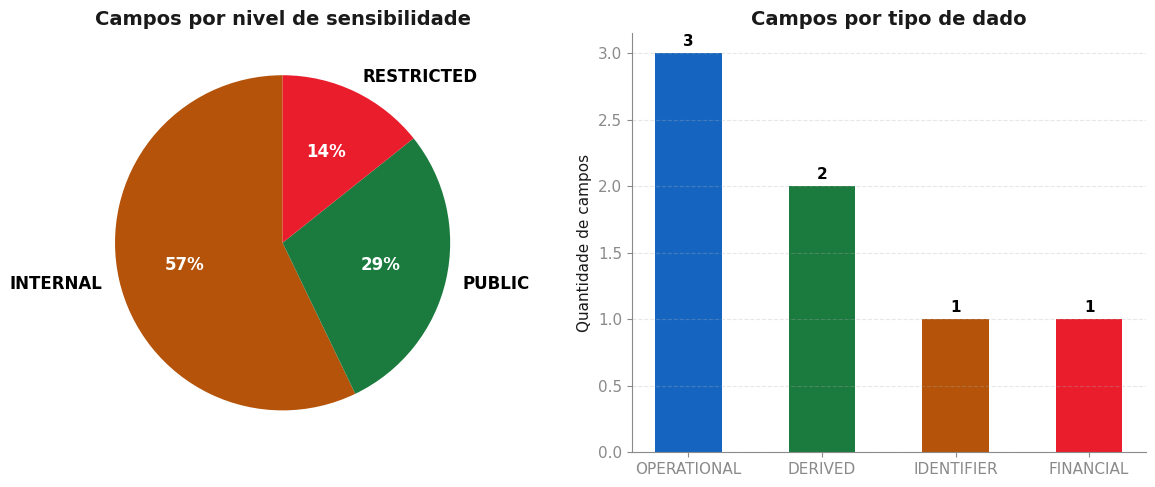


Implicacoes de governanca:
  RESTRICTED (total_amount): acesso controlado, auditoria obrigatoria.
  INTERNAL  (vendor, datetimes): somente times de dados e operacoes.
  PUBLIC    (derivados): sem identificacao direta, podem ser compartilhados.


In [0]:
# Grafico 5: Distribuicao de campos por nivel de sensibilidade
contagem = df_class["sensibilidade"].value_counts()
cores_class = {"RESTRICTED": IFOOD_RED, "INTERNAL": AMBER, "PUBLIC": GREEN}
cs = [cores_class.get(s, GRAY) for s in contagem.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pizza
wedges, texts, autotexts = ax1.pie(
    contagem.values, labels=contagem.index, colors=cs,
    autopct="%1.0f%%", startangle=90,
    textprops={"fontsize": 12, "fontweight": "bold"}
)
for at in autotexts:
    at.set_color("white")
ax1.set_title("Campos por nivel de sensibilidade")

# Detalhe por tipo
contagem_tipo = df_class["tipo"].value_counts()
cores_tipo = {"FINANCIAL": IFOOD_RED, "IDENTIFIER": AMBER, "OPERATIONAL": BLUE, "DERIVED": GREEN}
ct = [cores_tipo.get(t, GRAY) for t in contagem_tipo.index]
bars = ax2.bar(contagem_tipo.index, contagem_tipo.values, color=ct, width=0.5)
for b, v in zip(bars, contagem_tipo.values):
    ax2.annotate(str(v), (b.get_x() + b.get_width()/2, v),
                 textcoords="offset points", xytext=(0, 5), ha="center", fontweight="bold")
ax2.set_title("Campos por tipo de dado")
ax2.set_ylabel("Quantidade de campos")
ax2.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nImplicacoes de governanca:")
print("  RESTRICTED (total_amount): acesso controlado, auditoria obrigatoria.")
print("  INTERNAL  (vendor, datetimes): somente times de dados e operacoes.")
print("  PUBLIC    (derivados): sem identificacao direta, podem ser compartilhados.")

---
## Secao 4 – Analises do case

### Pergunta 1: Faturamento mensal
### Pergunta 2: Passageiros por hora

In [0]:
# Carga das tabelas Gold
df_receita = spark.table("ifood_case.gold.receita_mensal").orderBy("ano_mes").toPandas()
df_hora    = (spark.table("ifood_case.gold.passageiros_por_hora")
              .filter("ano_mes = '2023-05'").orderBy("hora_pickup").toPandas())

meses     = df_receita["ano_mes"].tolist()
ticket    = df_receita["ticket_medio_corrida"].astype(float).tolist()
receita   = df_receita["receita_total"].astype(float).tolist()
horas     = df_hora["hora_pickup"].astype(int).tolist()
media_pax = df_hora["media_passageiros"].astype(float).tolist()
volume    = df_hora["total_corridas"].astype(int).tolist()

print("Dados carregados.")

Dados carregados.


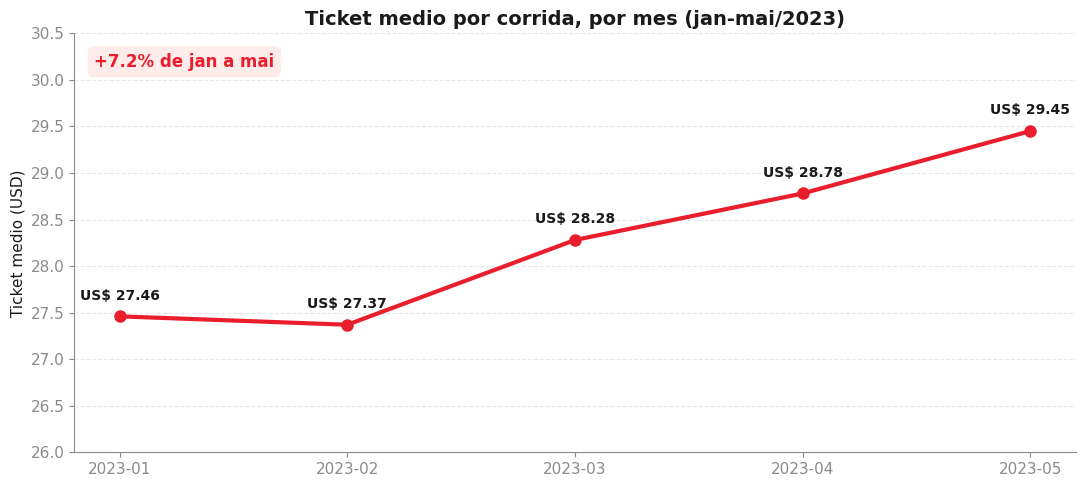

In [0]:
# Grafico 6: Ticket medio por mes (linha)
fig, ax = plt.subplots()
ax.plot(meses, ticket, color=IFOOD_RED, linewidth=3, marker="o", markersize=8)
for x, y in zip(meses, ticket):
    ax.annotate(f"US$ {y:.2f}", (x, y), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=10, color=DARK, fontweight="bold")
var = (ticket[-1] / ticket[0] - 1) * 100
ax.text(0.02, 0.92, f"+{var:.1f}% de jan a mai", transform=ax.transAxes,
        fontsize=12, color=IFOOD_RED, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDECEA", edgecolor="none"))
ax.set_title("Ticket medio por corrida, por mes (jan-mai/2023)")
ax.set_ylabel("Ticket medio (USD)"); ax.set_ylim(26, 30.5)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout(); plt.show()

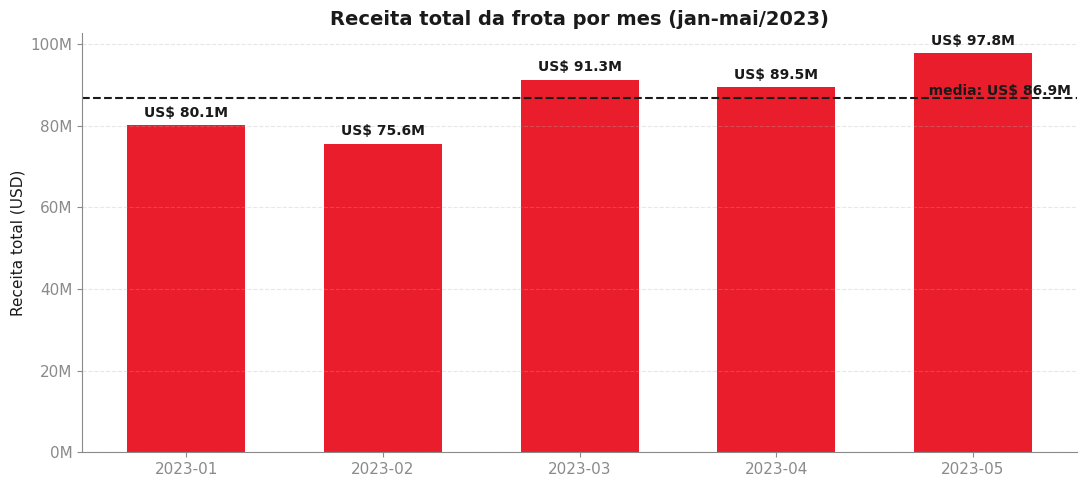

Receita media mensal: US$ 86,858,506.85


In [0]:
# Grafico 7: Receita total mensal (barras)
fig, ax = plt.subplots()
bars = ax.bar(meses, receita, color=IFOOD_RED, width=0.6)
for b, y in zip(bars, receita):
    ax.annotate(f"US$ {y/1e6:.1f}M", (b.get_x() + b.get_width()/2, y),
                textcoords="offset points", xytext=(0, 6), ha="center",
                fontsize=10, color=DARK, fontweight="bold")
media = sum(receita) / len(receita)
ax.axhline(media, color=DARK, linestyle="--", linewidth=1.5)
ax.text(len(meses)-0.5, media, f"  media: US$ {media/1e6:.1f}M",
        va="bottom", ha="right", color=DARK, fontsize=10, fontweight="bold")
ax.set_title("Receita total da frota por mes (jan-mai/2023)")
ax.set_ylabel("Receita total (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Receita media mensal: US$ {media:,.2f}")

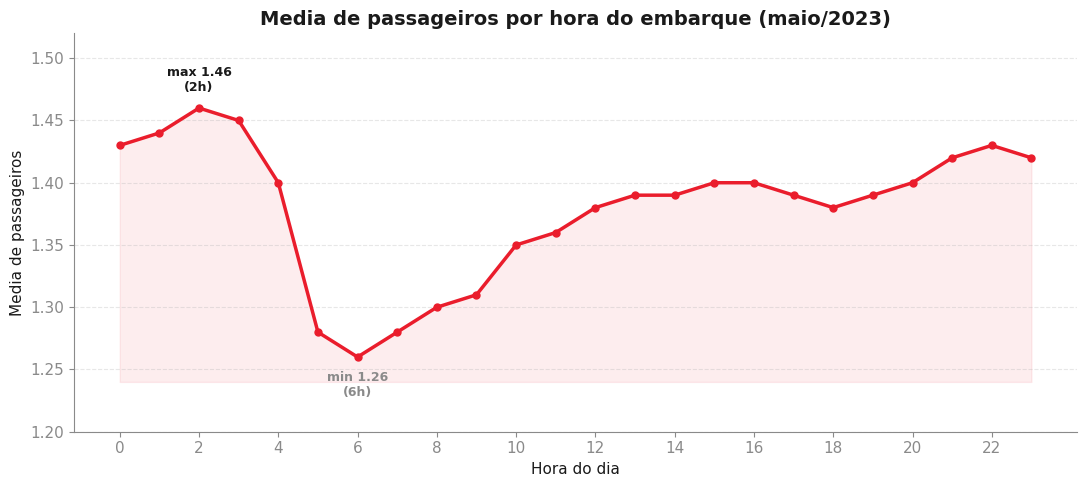

In [0]:
# Grafico 8: Media de passageiros por hora (linha)
fig, ax = plt.subplots()
ax.plot(horas, media_pax, color=IFOOD_RED, linewidth=2.5, marker="o", markersize=5)
ax.fill_between(horas, media_pax, min(media_pax)-0.02, color=IFOOD_RED, alpha=0.08)
i_max = media_pax.index(max(media_pax)); i_min = media_pax.index(min(media_pax))
ax.annotate(f"max {media_pax[i_max]:.2f}\n({horas[i_max]}h)",
            (horas[i_max], media_pax[i_max]), textcoords="offset points",
            xytext=(0, 12), ha="center", color=DARK, fontsize=9, fontweight="bold")
ax.annotate(f"min {media_pax[i_min]:.2f}\n({horas[i_min]}h)",
            (horas[i_min], media_pax[i_min]), textcoords="offset points",
            xytext=(0, -28), ha="center", color=GRAY, fontsize=9, fontweight="bold")
ax.set_title("Media de passageiros por hora do embarque (maio/2023)")
ax.set_xlabel("Hora do dia"); ax.set_ylabel("Media de passageiros")
ax.set_xticks(range(0, 24, 2)); ax.set_ylim(1.2, 1.52)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout(); plt.show()

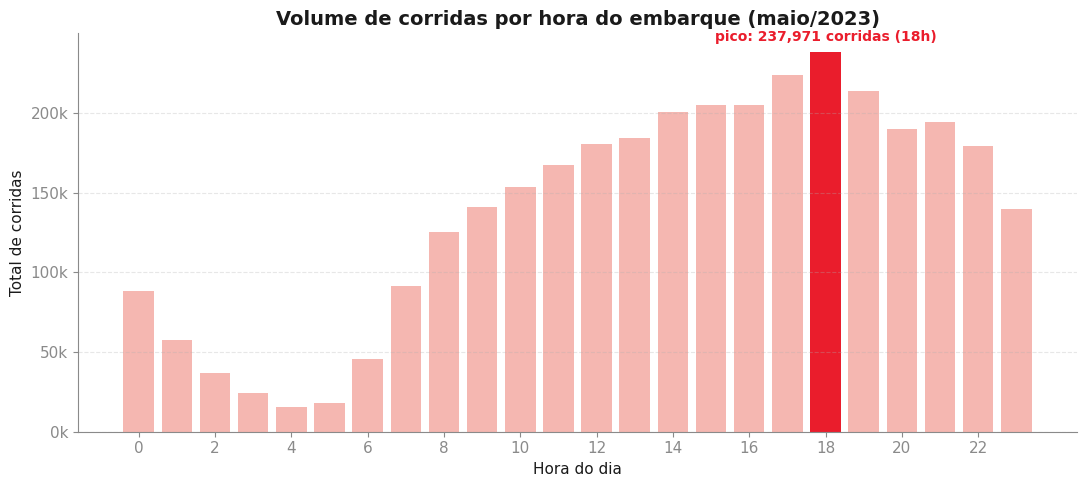

In [0]:
# Grafico 9: Volume de corridas por hora (barras)
cores_vol = [IFOOD_RED if v == max(volume) else "#F5B7B1" for v in volume]
fig, ax = plt.subplots()
bars = ax.bar(horas, volume, color=cores_vol, width=0.8)
i_pico = volume.index(max(volume))
ax.annotate(f"pico: {max(volume):,} corridas ({horas[i_pico]}h)",
            (horas[i_pico], volume[i_pico]), textcoords="offset points",
            xytext=(0, 8), ha="center", color=IFOOD_RED, fontsize=10, fontweight="bold")
ax.set_title("Volume de corridas por hora do embarque (maio/2023)")
ax.set_xlabel("Hora do dia"); ax.set_ylabel("Total de corridas")
ax.set_xticks(range(0, 24, 2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout(); plt.show()

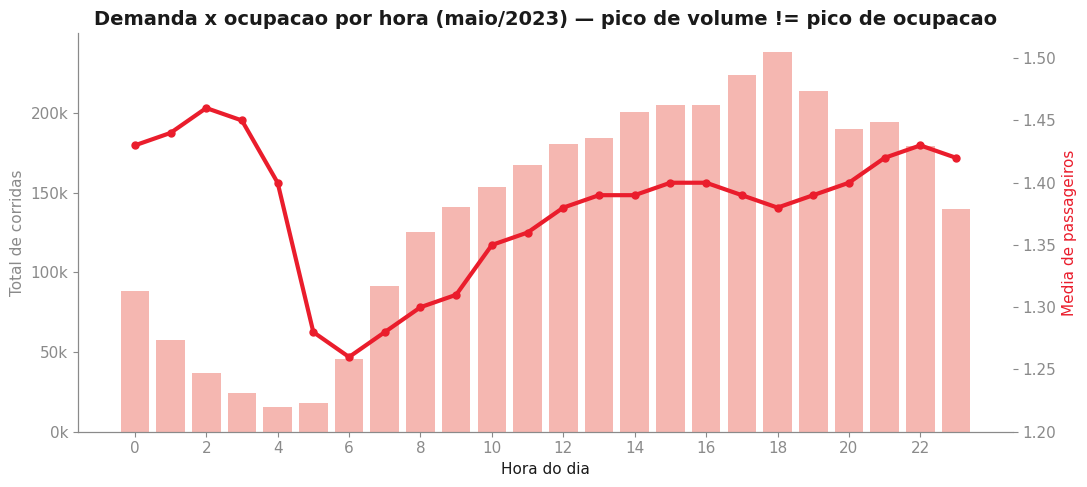

In [0]:
# Grafico 10: Combinado – volume x media de passageiros (eixo duplo)
fig, ax1 = plt.subplots()
ax1.bar(horas, volume, color="#F5B7B1", width=0.8)
ax1.set_xlabel("Hora do dia"); ax1.set_ylabel("Total de corridas", color=GRAY)
ax1.set_xticks(range(0, 24, 2))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}k"))
ax2 = ax1.twinx()
ax2.plot(horas, media_pax, color=IFOOD_RED, linewidth=3, marker="o", markersize=5)
ax2.set_ylabel("Media de passageiros", color=IFOOD_RED)
ax2.set_ylim(1.2, 1.52); ax2.spines["top"].set_visible(False)
ax1.set_title("Demanda x ocupacao por hora (maio/2023) — pico de volume != pico de ocupacao")
plt.tight_layout(); plt.show()

---
## Secao 5 – Conclusoes

### Qualidade de Dados
- Bronze tinha **849.249 registros invalidos** (5,24% do volume): nulos, estornos, timestamps errados e datas vazadas.
- Cada regra de limpeza foi justificada por evidencia do profiling — nao ha filtro arbitrario.
- Quality gate confirmou **0 violacoes** na Silver apos a limpeza.
- O `quality_log` registra o historico de cada execucao para auditoria continua.

### Governanca
- **total_amount** e o unico campo classificado como RESTRICTED/DADO_FINANCEIRO (LGPD Art. 5).
- Colunas derivadas (hora_pickup, ano_mes) sao PUBLIC pois nao permitem identificacao direta.
- A separacao Bronze/Silver/Gold e o `_ingestao_ts` garantem rastreabilidade de ponta a ponta.
- O Delta Lake fornece time travel para auditoria de versoes anteriores dos dados.

### Analises
- Ticket medio subiu **+7,2%** de jan a mai (US$ 27,46 → US$ 29,45): alta sazonal de primavera.
- Receita media mensal da frota: **~US$ 86,8 milhoes/mes**.
- O pico de **volume** de corridas (18h, 237.971 corridas) nao coincide com o pico de **ocupacao** (02h, 1,46 pax).
- Yellow taxi de NY e majoritariamente um **modal individual** (banda 1,26–1,46 o dia todo).
